# Tutorial 04: Reinforcement Learning with Verifiable Rewards

Supervised fine-tuning teaches a model from example outputs. Reinforcement learning (RL) teaches from *rewards* -- the model generates its own outputs, and a reward function scores them. The model learns to produce outputs that score higher.

In this tutorial, you will:

1. Define a reward function that checks math answers for correctness
2. Run a GRPO-style RL loop on GSM8K (grade school math) problems
3. Watch the model's accuracy improve over training steps

## How GRPO works

GRPO (Group Relative Policy Optimization) is a simple RL algorithm for language models:

1. **Sample a batch of problems** from the dataset
2. **Generate `group_size` completions** per problem using the current model
3. **Grade each completion** with a reward function (e.g., is the math answer correct?)
4. **Compute group-relative advantages**: `advantage = reward - mean(rewards_in_group)`
5. **Train** on the completions, weighted by their advantages

The key insight: by comparing completions *within each group*, the model learns which outputs are better than average for each problem. Correct answers get positive advantage, wrong ones get negative advantage.

In [1]:
import re

import tinker
import torch
from tinker import TensorData

from tinker_cookbook.renderers import get_renderer, get_text_content

## Setup

Create a LoRA training client and a renderer. We use Llama-3.1-8B (a base/pretrained model) since RL works well from a base model that has broad knowledge but hasn't been instruction-tuned.

In [2]:
base_model = "meta-llama/Llama-3.1-8B"

service_client = tinker.ServiceClient()
training_client = service_client.create_lora_training_client(base_model=base_model, rank=32)
tokenizer = training_client.get_tokenizer()
renderer = get_renderer("llama3", tokenizer)

sampling_params = tinker.SamplingParams(
    max_tokens=256,
    stop=renderer.get_stop_sequences(),
)
adam_params = tinker.AdamParams(learning_rate=4e-5, beta1=0.9, beta2=0.95)

/Users/yujia/Repos/tinker-cookbook/.claude/worktrees/quirky-discovering-lightning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The reward function

For GSM8K, the reward function is simple: extract the number from inside `\boxed{}` in the model's response, and compare it to the ground truth answer. Binary reward: 1.0 if correct, 0.0 if wrong.

In [3]:
def extract_boxed(text: str) -> str | None:
    """Extract content from the last \\boxed{...} in text."""
    match = re.findall(r"\\boxed\{([^}]+)\}", text)
    if match:
        return match[-1].strip()
    return None


def grade_answer(response: str, ground_truth: str) -> float:
    """Return 1.0 if the boxed answer matches ground truth, 0.0 otherwise."""
    answer = extract_boxed(response)
    if answer is None:
        return 0.0
    # Normalize: strip whitespace, commas, and compare
    answer = answer.replace(",", "").strip()
    ground_truth = ground_truth.replace(",", "").strip()
    return 1.0 if answer == ground_truth else 0.0

## Load GSM8K problems

We load a small slice of the GSM8K training set. Each problem has a `question` and an `answer` field. We extract the final numeric answer from the answer field (it follows `####`).

In [4]:
import datasets

dataset = datasets.load_dataset("openai/gsm8k", "main")
train_data = dataset["train"]


def extract_gsm8k_answer(text: str) -> str:
    """Extract the final answer after #### in a GSM8K solution."""
    match = re.search(r"####\s*(.+)", text)
    if match:
        return match.group(1).replace(",", "").strip()
    raise ValueError("No #### answer found")


# Use a few-shot prefix to teach the base model the expected format
question_suffix = " Provide a numerical answer without units, written inside \\boxed{}."
fewshot_prefix = [
    {"role": "user", "content": "How many r's are in strawberry?" + question_suffix},
    {
        "role": "assistant",
        "content": (
            "Let's spell the word out and number all the letters: "
            "1) s 2) t 3) r 4) a 5) w 6) b 7) e 8) r 9) r 10) y. "
            "We have r's at positions 3, 8, and 9. \\boxed{3}"
        ),
    },
]

print(f"Loaded {len(train_data)} GSM8K training problems")

Loaded 7473 GSM8K training problems


## The RL training loop

Here is the full GRPO loop. For each training step:

1. **Save weights** and create a sampling client (the sampler must use the current policy)
2. **Sample completions** -- for each problem, generate `group_size` responses
3. **Grade and compute advantages** -- reward each response, then center within each group
4. **Skip degenerate groups** -- if all completions got the same reward, the advantage is zero everywhere, so there is no learning signal
5. **Build datums** with `importance_sampling` loss using the sampling logprobs and advantages
6. **Train** with `forward_backward` + `optim_step`

In [5]:
from concurrent.futures import Future

# Training hyperparameters
n_steps = 10
batch_size = 16  # problems per step
group_size = 8  # completions per problem

# Tracking metrics
metrics_history = []

for step in range(n_steps):
    # 1. Get the batch of problems for this step
    batch_start = step * batch_size
    batch_end = batch_start + batch_size
    batch_rows = train_data.select(range(batch_start, batch_end))

    # 2. Save current weights and create a sampling client
    sampling_client = training_client.save_weights_and_get_sampling_client()

    # 3. Submit all sampling requests (non-blocking)
    futures_P: list[Future] = []
    prompts_P: list[tinker.ModelInput] = []
    for question in batch_rows["question"]:
        convo = [*fewshot_prefix, {"role": "user", "content": question + question_suffix}]
        prompt = renderer.build_generation_prompt(convo)
        future = sampling_client.sample(
            prompt=prompt, num_samples=group_size, sampling_params=sampling_params
        )
        futures_P.append(future)
        prompts_P.append(prompt)

    # 4. Collect results, grade, compute advantages, build datums
    datums_D: list[tinker.Datum] = []
    rewards_P: list[float] = []
    n_degenerate = 0

    for future, prompt, answer_text in zip(futures_P, prompts_P, batch_rows["answer"]):
        ground_truth = extract_gsm8k_answer(answer_text)
        sample_result = future.result()

        # Grade each completion in the group
        rewards_G: list[float] = []
        tokens_G_T: list[list[int]] = []
        logprobs_G_T: list[list[float]] = []

        for sequence in sample_result.sequences:
            tokens_G_T.append(sequence.tokens)
            logprobs_G_T.append(sequence.logprobs)
            parsed_message, _ = renderer.parse_response(sequence.tokens)
            content = get_text_content(parsed_message)
            reward = grade_answer(content, ground_truth)
            rewards_G.append(reward)

        # Group-relative advantages
        mean_reward = sum(rewards_G) / len(rewards_G)
        advantages_G = [r - mean_reward for r in rewards_G]
        rewards_P.append(mean_reward)

        # Skip degenerate groups (all same reward -> zero advantage -> no signal)
        if all(a == 0.0 for a in advantages_G):
            n_degenerate += 1
            continue

        # Build a Datum for each completion
        ob_len = prompt.length - 1
        for tokens, logprobs, advantage in zip(tokens_G_T, logprobs_G_T, advantages_G):
            model_input = prompt.append(tinker.EncodedTextChunk(tokens=tokens[:-1]))
            target_tokens = [0] * ob_len + tokens
            padded_logprobs = [0.0] * ob_len + logprobs
            padded_advantages = [0.0] * ob_len + [advantage] * (model_input.length - ob_len)

            datum = tinker.Datum(
                model_input=model_input,
                loss_fn_inputs={
                    "target_tokens": TensorData.from_torch(torch.tensor(target_tokens)),
                    "logprobs": TensorData.from_torch(torch.tensor(padded_logprobs)),
                    "advantages": TensorData.from_torch(torch.tensor(padded_advantages)),
                },
            )
            datums_D.append(datum)

    # 5. Training step
    if len(datums_D) > 0:
        fwd_bwd_future = training_client.forward_backward(datums_D, loss_fn="importance_sampling")
        optim_future = training_client.optim_step(adam_params)
        fwd_bwd_future.result()
        optim_future.result()

    mean_reward = sum(rewards_P) / len(rewards_P)
    frac_degenerate = n_degenerate / len(rewards_P)
    metrics_history.append(
        {"step": step, "reward": mean_reward, "frac_degenerate": frac_degenerate}
    )

    print(
        f"Step {step:2d} | reward: {mean_reward:.3f} | "
        f"degenerate: {frac_degenerate:.0%} | datums: {len(datums_D)}"
    )

Step  0 | reward: 0.055 | degenerate: 75% | datums: 32


Step  1 | reward: 0.031 | degenerate: 75% | datums: 32


Step  2 | reward: 0.047 | degenerate: 69% | datums: 40


Step  3 | reward: 0.078 | degenerate: 50% | datums: 64


Step  4 | reward: 0.070 | degenerate: 56% | datums: 56


Step  5 | reward: 0.078 | degenerate: 62% | datums: 48


Step  6 | reward: 0.078 | degenerate: 50% | datums: 64


Step  7 | reward: 0.086 | degenerate: 56% | datums: 56


Step  8 | reward: 0.070 | degenerate: 50% | datums: 64


Step  9 | reward: 0.094 | degenerate: 50% | datums: 64


## Plot the reward curve

The mean reward should trend upward as the model learns to solve more problems correctly.

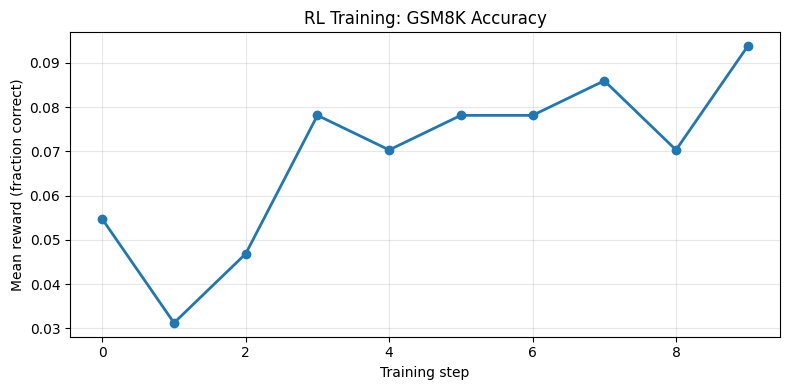

In [6]:
import matplotlib.pyplot as plt

steps = [m["step"] for m in metrics_history]
rewards = [m["reward"] for m in metrics_history]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, rewards, marker="o", linewidth=2)
ax.set_xlabel("Training step")
ax.set_ylabel("Mean reward (fraction correct)")
ax.set_title("RL Training: GSM8K Accuracy")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Key concepts recap

- **Group-relative advantages** center rewards within each group, so the model learns which completions are *relatively* better for each problem. This is more stable than using raw rewards.
- **Degenerate groups** occur when all completions in a group get the same reward (all correct or all wrong). These produce zero advantages and are skipped -- they carry no learning signal.
- **`importance_sampling` loss** handles the off-policy correction between the sampling policy and the current training policy, using the logprobs recorded during sampling.
- **Datum construction** for RL: the prompt tokens get zero advantage (we don't want to change how the model reads the prompt), and the completion tokens get the group-relative advantage.

## Next steps

- **Tutorial 05** (`05_custom_task.ipynb`): Adapt this pattern to your own task with a custom reward function
- **Production recipes**: See `tinker_cookbook/recipes/rl_loop.py` for a minimal script and `tinker_cookbook/recipes/math_rl/` for a full-featured GSM8K/MATH training setup
- **Scaling up**: The [RL Hyperparameters](https://tinker-cookbook.thinkingmachines.ai/rl/rl-hyperparams) guide covers batch size, group size, learning rates, and async training for larger runs
- **Custom environments**: The [RL Environments](https://tinker-cookbook.thinkingmachines.ai/rl/rl-envs) guide shows how to define multi-step environments using the `Env` / `EnvGroupBuilder` / `RLDataset` abstractions